In [7]:
import numpy as np
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
from tqdm import tqdm

bond_distance = np.round(np.linspace(0.8,3.4,15),2)

In [8]:
LiH_E_FCI = []
LiH_E_HF = []
H2_nuclear_repulsion = []
for bond_length in tqdm(bond_distance):
    geometry = [
        ('Li', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
    ]

    # 创建分子对象，使用STO-3G基组
    mol = gto.M(atom=geometry, basis='STO-3G')

    # 进行Hartree-Fock计算
    mf = scf.RHF(mol).run(verbose=0)
    E_hf = mf.e_tot
    
    # 进行FCI计算作为参考
    cisolver = fci.FCI(mf)
    E_fci, fcivec = cisolver.kernel()
    LiH_E_FCI.append(E_fci)
    LiH_E_HF.append(E_hf)
    
with open('LiH_E_FCI_HF.npz', 'wb') as f:
    np.savez(f, E_FCI=LiH_E_FCI, E_HF=LiH_E_HF, bond_length=bond_distance)
    

100%|██████████| 15/15 [00:01<00:00, 12.67it/s]


In [9]:
with open('LiH_E_FCI_HF.npz', 'rb') as f:
    data = np.load(f)
    E_FCI = data['E_FCI']      # 不是 E_fci
    E_HF = data['E_HF']
    bond_length = data['bond_length']

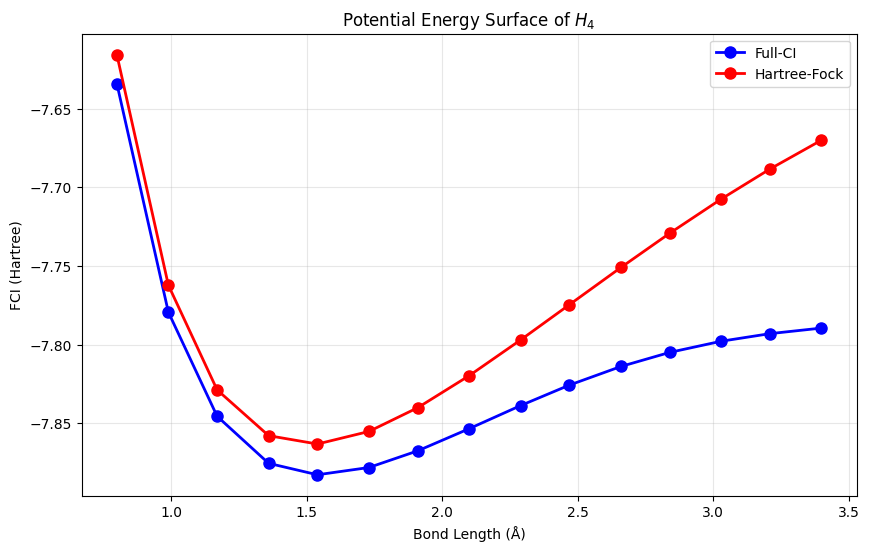

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(bond_length, E_FCI, 'bo-', linewidth=2, markersize=8,label='Full-CI')
plt.plot(bond_length, E_HF, 'ro-', linewidth=2, markersize=8,label='Hartree-Fock')
#plt.plot(bond_length, E_FFNN, 'go-', linewidth=2, markersize=8,label='VMC')
plt.legend()
plt.xlabel('Bond Length (Å)')
plt.ylabel('FCI (Hartree)')

plt.title('Potential Energy Surface of $H_4$')
plt.grid(True, alpha=0.3)
plt.show()

VMC计算

In [ ]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)
cluster = [(0,1),(2,3)]
g = nk.graph.Graph(edges=[(0,1),(2,3)])
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [ ]:
import jax
import jax.numpy as jnp
from flax import nnx

class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs,param_dtype=complex)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)

N = 4
ffnn_model = FFN(N=N, alpha=2, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

FFNN的计算结果

In [ ]:
ffnn_energy=[]
for bond_length in tqdm(bond_distance):
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
    ]
    # 创建分子对象，使用STO-3G基组
    mol = gto.M(atom=geometry, basis='STO-3G')
    ha = nkx.operator.from_pyscf_molecule(mol)
    gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
    gs.run(200)
    ffnn_energy.append(gs.energy.mean)

In [ ]:
ffnn_energy

In [ ]:
with open('H2_FFNN_alpha_2.npz', 'wb') as f:
    np.savez(f, E_FFNN=ffnn_energy, bond_length=bond_distance)

In [ ]:
with open('H2_FFNN.npz', 'rb') as f:
    data = np.load(f)
    E_FFNN = data['E_FFNN']
    bond_length = data['bond_length']
    
with open('H2_E_FCI_HF.npz', 'rb') as f:
    data = np.load(f)
    E_FCI = data['E_FCI']      # 不是 E_fci
    E_HF = data['E_HF']
    E_nuclear_repulsion = data['E_nuclear_repulsion']
    bond_length = data['bond_length']

In [ ]:
E_FFNN

In [ ]:
from cProfile import label
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(bond_length, E_FCI, 'bo-', linewidth=2, markersize=8,label='Full-CI')
plt.plot(bond_length, E_HF, 'ro-', linewidth=2, markersize=8,label='Hartree-Fock')
plt.plot(bond_length, E_FFNN, 'go-', linewidth=2, markersize=8,label='Neural Network alpha=1 VMC')

plt.legend()
plt.xlabel('Bond Length (Å)')
plt.ylabel('FCI (Hartree)')

plt.title('Potential Energy Surface of H2')
plt.grid(True, alpha=0.3)
plt.show()